In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('food_delivery.csv')

In [3]:
df.shape

(100, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   OrderID       100 non-null    int64
 1   Customer      100 non-null    str  
 2   FoodItem      100 non-null    str  
 3   Quantity      100 non-null    int64
 4   Price         100 non-null    int64
 5   TotalAmount   100 non-null    int64
 6   DeliveryTime  100 non-null    int64
 7   PaymentMode   100 non-null    str  
dtypes: int64(5), str(3)
memory usage: 6.4 KB


In [5]:
df.sample(5)

,OrderID,Customer,FoodItem,Quantity,Price,TotalAmount,DeliveryTime,PaymentMode
72,5073,Cust_73,Biryani,4,580,2320,37,Cash
77,5078,Cust_78,Pizza,2,445,890,30,Cash
80,5081,Cust_81,Biryani,3,230,690,33,Card
38,5039,Cust_39,Pizza,1,445,445,29,Card
9,5010,Cust_10,Pizza,4,557,2228,53,Card


# NUMPY

In [6]:
np.average(df['DeliveryTime'])

np.float64(33.48)

In [7]:
avg_delivery = np.average(df['DeliveryTime'])


# Or keep one decimal place
print(f"{avg_delivery:.1f} minutes")


33.5 minutes


In [8]:
np.max(df['TotalAmount'])

np.int64(3630)

In [9]:
np.min(df['Price'])

np.int64(112)

# PANDAS

In [10]:
df.sample(3)

,OrderID,Customer,FoodItem,Quantity,Price,TotalAmount,DeliveryTime,PaymentMode
18,5019,Cust_19,Biryani,5,400,2000,12,Cash
33,5034,Cust_34,Pizza,1,693,693,42,Card
74,5075,Cust_75,Pasta,1,639,639,25,Card


In [11]:
df.groupby('FoodItem')['TotalAmount'].sum().sort_values(ascending=False).head(5)
# by total amount

FoodItem
Biryani     29004
Pasta       28446
Burger      27379
Sandwich    24772
Pizza       23252
Name: TotalAmount, dtype: int64

In [12]:
df.groupby('FoodItem')['TotalAmount'].sum().sort_values(ascending=False).head(5)  #by quantity sold


FoodItem
Biryani     29004
Pasta       28446
Burger      27379
Sandwich    24772
Pizza       23252
Name: TotalAmount, dtype: int64

In [13]:
df.loc[df['DeliveryTime'] > 45, ['FoodItem', 'DeliveryTime']].head()

,FoodItem,DeliveryTime
0,Sandwich,56
8,Burger,58
9,Pizza,53
10,Biryani,59
11,Pasta,55


In [14]:
df.groupby('PaymentMode')['OrderID'].count()

PaymentMode
Card    34
Cash    31
UPI     35
Name: OrderID, dtype: int64

In [15]:
df[df['TotalAmount'] > df['TotalAmount'].mean()].head()

,OrderID,Customer,FoodItem,Quantity,Price,TotalAmount,DeliveryTime,PaymentMode
2,5003,Cust_3,Sandwich,5,544,2720,19,UPI
8,5009,Cust_9,Burger,5,617,3085,58,Card
9,5010,Cust_10,Pizza,4,557,2228,53,Card
10,5011,Cust_11,Biryani,2,749,1498,59,Cash
11,5012,Cust_12,Pasta,5,505,2525,55,Cash


In [16]:
# df[['']].sort_values(by = 'TotalAmount',ascending=False)
df.sort_values(by='TotalAmount', ascending=False)


,OrderID,Customer,FoodItem,Quantity,Price,TotalAmount,DeliveryTime,PaymentMode
91,5092,Cust_92,Burger,5,726,3630,58,Card
68,5069,Cust_69,Sandwich,5,723,3615,15,Cash
48,5049,Cust_49,Biryani,5,710,3550,31,UPI
42,5043,Cust_43,Burger,4,781,3124,49,Card
17,5018,Cust_18,Burger,4,775,3100,37,Card
...,...,...,...,...,...,...,...,...
41,5042,Cust_42,Sandwich,1,198,198,42,Card
21,5022,Cust_22,Biryani,1,188,188,23,UPI
99,5100,Cust_100,Pizza,1,187,187,39,UPI
93,5094,Cust_94,Pizza,1,174,174,12,UPI


In [17]:
df.sort_values(by='TotalAmount', ascending=False)[['OrderID','Customer','TotalAmount']]


,OrderID,Customer,TotalAmount
91,5092,Cust_92,3630
68,5069,Cust_69,3615
48,5049,Cust_49,3550
42,5043,Cust_43,3124
17,5018,Cust_18,3100
...,...,...,...
41,5042,Cust_42,198
21,5022,Cust_22,188
99,5100,Cust_100,187
93,5094,Cust_94,174


# MATPLOTLIB

In [18]:
df.sample(5)

,OrderID,Customer,FoodItem,Quantity,Price,TotalAmount,DeliveryTime,PaymentMode
24,5025,Cust_25,Sandwich,5,489,2445,43,Card
76,5077,Cust_77,Pasta,3,721,2163,45,UPI
9,5010,Cust_10,Pizza,4,557,2228,53,Card
16,5017,Cust_17,Sandwich,2,573,1146,55,UPI
17,5018,Cust_18,Burger,4,775,3100,37,Card


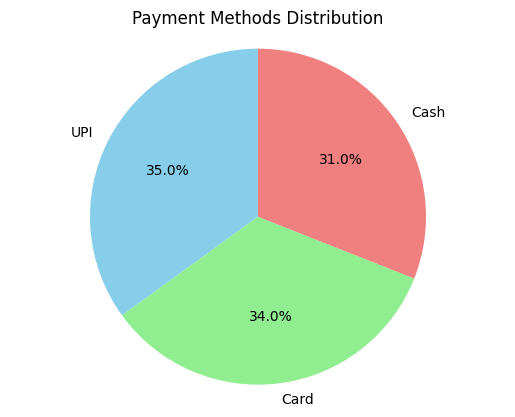

In [19]:
import matplotlib.pyplot as plt

# Count payment methods
payment_counts = df['PaymentMode'].value_counts()

# Plot pie chart
payment_counts.plot(
    kind='pie',
    autopct='%1.1f%%',   # show percentages
    startangle=90,       # rotate chart for better look
    colors=['skyblue', 'lightgreen', 'lightcoral', 'gold']  # optional styling
)

# Add title
plt.title('Payment Methods Distribution')

# Equal aspect ratio ensures pie is drawn as a circle
plt.axis('equal')

plt.show()


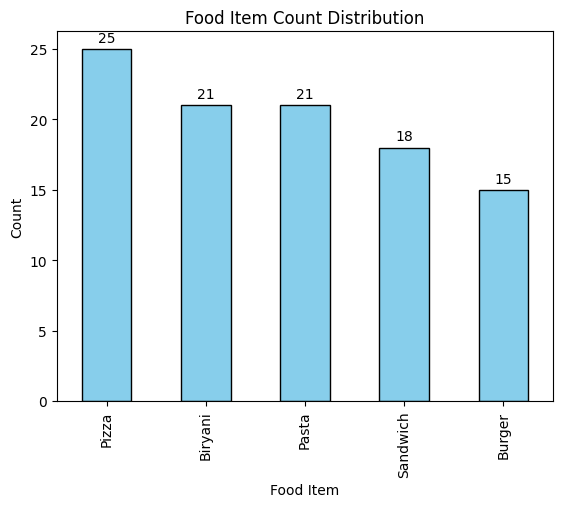

In [20]:
import matplotlib.pyplot as plt

# Count food items
food_counts = df['FoodItem'].value_counts()

# Plot bar chart
food_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('Food Item')
plt.ylabel('Count')
plt.title('Food Item Count Distribution')

# Add counts on top of bars
for i, count in enumerate(food_counts.values):
    plt.text(i, count + 0.5, str(count), ha='center')

plt.show()


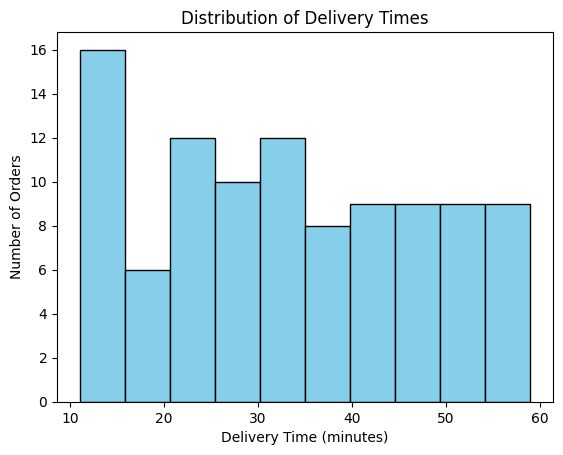

In [21]:
import matplotlib.pyplot as plt

# Histogram of DeliveryTime column
plt.hist(df['DeliveryTime'], bins=10, edgecolor='black', color='skyblue')

# Add labels and title
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Number of Orders')
plt.title('Distribution of Delivery Times')

plt.show()
